In this module we see ```Time series decomposition using Classical Model```


Time Series data refer to data that is collect, recorded or observed over time in a sequential order.

Characteristics:
1. Chronological Order: Observation are ordered in time(D,W,M,Y,s,m,h)(day,week,month,year,sec,min,hour)
2. Sequential Order: The order of data matters because previous  value can influence or predict the future values.
3. Temporal Components: Trend,Seasonality, Cycle,noise

Time series Analysis:
* statistical technique: meaning insights about pattern and trends.
* forecasting

Time Series Decomposition

* Trend: long term direction
* Seasonality: repeting pattern at fixed interval.
* Noise  ( will not be capture)

```Classical Decomposition```


In [15]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt 
import seaborn as sns

In [16]:
df=pd.read_csv("AirPassengers.csv",parse_dates=["Month"],index_col="Month")
df=df.rename(columns={'#Passengers':'Passengers'})
df

,Passengers
Month,
1949-01-01,112
1949-02-01,118
1949-03-01,132
1949-04-01,129
1949-05-01,121
...,...
1960-08-01,606
1960-09-01,508
1960-10-01,461


Text(0, 0.5, 'Passenger')

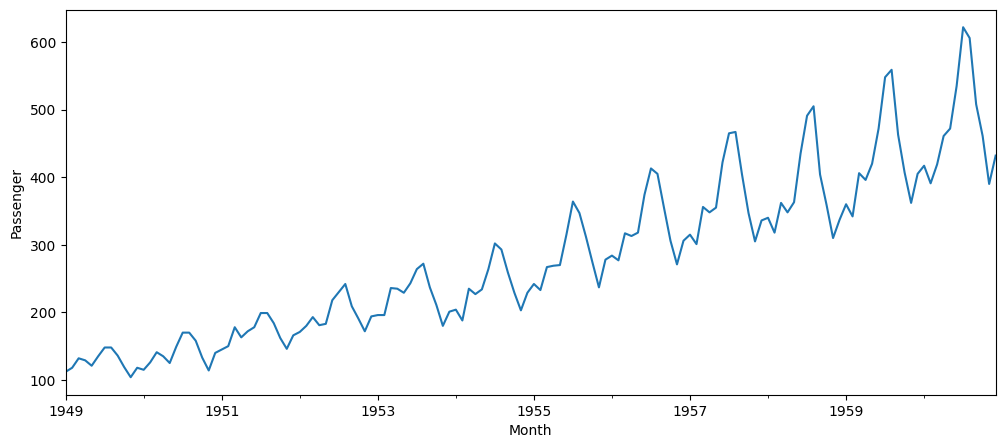

In [17]:
df["Passengers"].plot(figsize=(12,5))
plt.xlabel("Month")
plt.ylabel("Passenger")

The graph show the seasonality because we see same pattern in every year only they are magnifiying each year the follow same patter. It show seasonalty. Some amount of noise also available but we are not able to capture by trend or season.

So what we do to capture Noise. Let say we have trend component or season component. So what we should do,add all decomposition or multiply all decomposition to get the final time series. 
There are two way to do it:
* ```Additive Model```
* ```Multiplicative Model```

When apply "Additive Model" when you see graph is very constant i.e the peek and bottom are same size. Its ia upward trend okay and not changing across time.When we see balanced trend across over time. When we have this type of chart we use Additive Model. here trend is linear. Above graph show Additive model behaviour.

When apply "Multiplicative Model" when you see small grow in early days and later on it is increase so when graph grow exponentially . In  this case we should do multiplication of trend and season. here trend is exponential.
 

Additive ```yi=T+S+R ```  (if we want to predict yi and if I want what is my time series data is its going to be (Trend)+(season)+(Residual or Noise))

Multiplicative ```yi=T*S*R```  (if we want to predict yi and if I want what is my time series data is its going to be (Trend)*(season)*(Residual or Noise))


From graph we decide which type of model we have to build.

In [18]:
import yfinance as yf
ticker_symbol='Reliance.NS'
stock_data=yf.download(ticker_symbol,start='2023-01-01',end='2025-08-01',interval="1d")
stock_data

[*********************100%***********************]  1 of 1 completed


Price,Close,High,Low,Open,Volume
Ticker,RELIANCE.NS,RELIANCE.NS,RELIANCE.NS,RELIANCE.NS,RELIANCE.NS
Date,,,,,
2023-01-02,1175.889648,1177.304802,1163.244669,1164.066352,5316175
2023-01-03,1167.284668,1174.565828,1163.062148,1170.936659,7658932
2023-01-04,1149.709595,1169.110728,1147.632506,1167.261851,9264891
2023-01-05,1147.655396,1157.858149,1143.067616,1151.969321,13637099
2023-01-06,1158.086304,1163.130627,1149.595501,1153.407240,6349597
...,...,...,...,...,...
2025-07-25,1386.163696,1395.426749,1378.593954,1393.335127,11854722
2025-07-28,1382.080078,1402.199795,1379.490445,1386.761454,7748361


In [19]:
stock_data.columns=stock_data.columns.droplevel("Ticker")
stock_data

Price,Close,High,Low,Open,Volume
Date,,,,,
2023-01-02,1175.889648,1177.304802,1163.244669,1164.066352,5316175
2023-01-03,1167.284668,1174.565828,1163.062148,1170.936659,7658932
2023-01-04,1149.709595,1169.110728,1147.632506,1167.261851,9264891
2023-01-05,1147.655396,1157.858149,1143.067616,1151.969321,13637099
2023-01-06,1158.086304,1163.130627,1149.595501,1153.407240,6349597
...,...,...,...,...,...
2025-07-25,1386.163696,1395.426749,1378.593954,1393.335127,11854722
2025-07-28,1382.080078,1402.199795,1379.490445,1386.761454,7748361
2025-07-29,1411.462769,1414.550412,1377.498442,1377.498442,10750072


In [20]:
type(stock_data.index)

pandas.core.indexes.datetimes.DatetimeIndex

<Axes: xlabel='Date'>

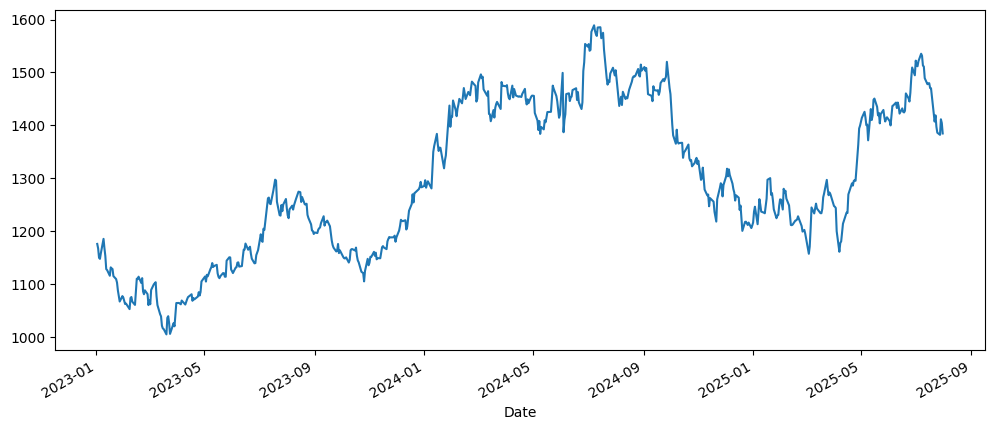

In [21]:
stock_data['Close'].plot(figsize=(12,5))

Hard to say which type of seasonality that follow it's uptrend or downtrend. No any clear seasonality but some seasonality present. From 2023-05 to 2023-07 we see uptrend from 2023-07 to earlier 2024-01 show downtrend. In some region we see no seasonality like mid of 2024-01 to mid of 2024-09.

In above graph seasonality is not clear. so we not clearly give any insight from that graph. For such graph we use model to understand seasonality.

In [22]:
from statsmodels.tsa.seasonal import seasonal_decompose
sd=seasonal_decompose(df["Passengers"],model="multiplicative",period=10)
#  We make multiplicate model because trend is not linear. we do experiment on period value.
# For seasonal decompose we always take a column not entire data.
# Period represent in how many period they repeat seasonality. We have to do experiment on that.

In [23]:
# sd give three thing -> Trend, Seasonality, Residual 
trend=sd.trend
seasonal=sd.seasonal
residuals=sd.resid

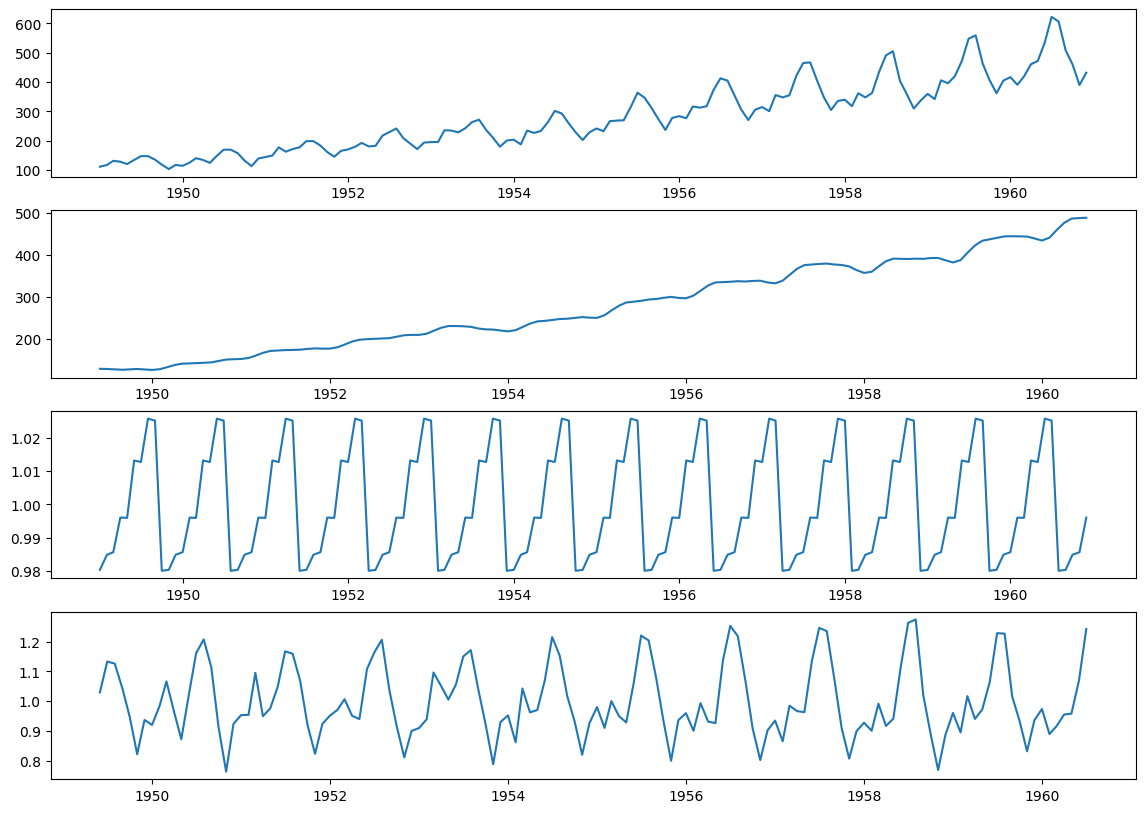

In [24]:
plt.figure(figsize=(14,10))
plt.subplot(411)
plt.plot(df["Passengers"])
plt.subplot(412)
plt.plot(trend)
plt.subplot(413)
plt.plot(seasonal)
plt.subplot(414)
plt.plot(residuals)
plt.show()

First image is show the attribute "Passenger".
Second Image show Trend. From graph it is clear, it follow uptrend.
Third image show seasonality. We see same pattern in some period of time.
Fourth one represent noise or residual which not easy to capture.
 

<Axes: xlabel='Date'>

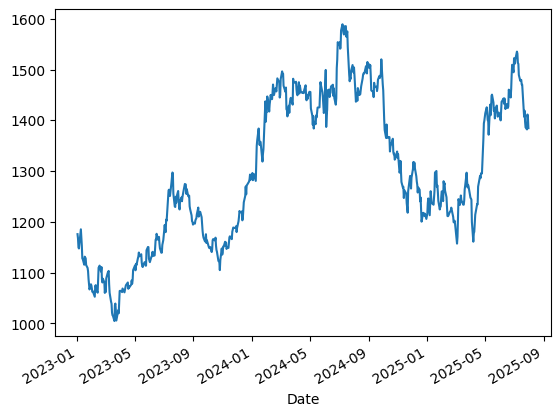

In [25]:
stock_data["Close"].plot()

In [26]:
sd=seasonal_decompose(stock_data["Close"],model="additive",period=10)

In [31]:
trend=sd.trend
seasonal=sd.seasonal
residuals=sd.resid

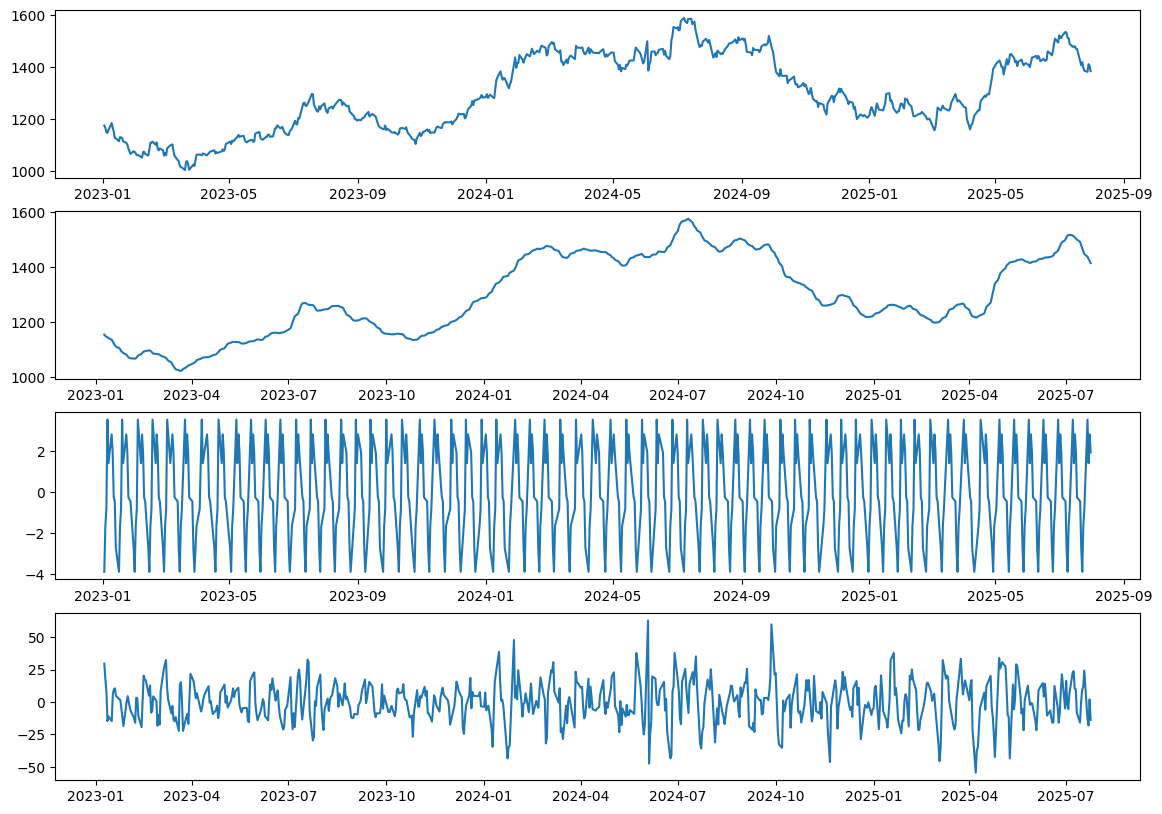

In [32]:
plt.figure(figsize=(14,10))
plt.subplot(411)
plt.plot(stock_data["Close"])
plt.subplot(412)
plt.plot(trend)
plt.subplot(413)
plt.plot(seasonal)
plt.subplot(414)
plt.plot(residuals)
plt.show()


What are some issue in seasonal decomposition:
1. Assumes fixed seasonal patterns.  (fixed seasonal pattern is not good)
2. Easily influenced by the outliers.
3. Handle both additive and multiplicative models.
4. Preferred for multiplicative models.


Let trend + seasonal is my estimation(target)

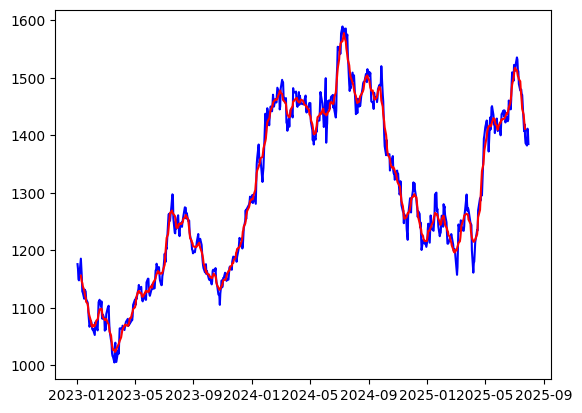

In [34]:
estimated=trend+seasonal
plt.plot(stock_data["Close"],color="blue")  # it show True label i.e Close value represent by blue color.
plt.plot(estimated,color="red")    # Estimated label represent by Red color.
plt.show()

"Blue color" represent True Close value.
"Red color" represent estimated Close value.
It is  a good estimation because mostly red line cover blue line.

In [35]:
estimated.fillna(0)

Date
2023-01-02    0.0
2023-01-03    0.0
2023-01-04    0.0
2023-01-05    0.0
2023-01-06    0.0
             ... 
2025-07-25    0.0
2025-07-28    0.0
2025-07-29    0.0
2025-07-30    0.0
2025-07-31    0.0
Length: 637, dtype: float64

In [37]:
from sklearn.metrics import  mean_squared_error
mean_squared_error(stock_data["Close"],estimated.fillna(0))

26045.52682570851